In [24]:
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd

# ------------------- MMD loss with safeguard -------------------
def mmd_loss(x, y, sigma_min=1e-3):
    if x.dim() == 1:
        x = x.unsqueeze(1)
        y = y.unsqueeze(1)

    n, m = x.size(0), y.size(0)

    xx = torch.cdist(x, x, p=2).pow(2)
    yy = torch.cdist(y, y, p=2).pow(2)
    xy = torch.cdist(x, y, p=2).pow(2)

    with torch.no_grad():
        all_d2 = torch.cat([xx.flatten(), yy.flatten(), xy.flatten()])
        sigma_sq = torch.median(all_d2)
        sigma_sq = sigma_sq.clamp(min=sigma_min**2)
        sigma = sigma_sq.sqrt()
    simga = sigma*100
    K_xx = torch.exp(-xx / (2 * sigma**2))
    K_yy = torch.exp(-yy / (2 * sigma**2))
    K_xy = torch.exp(-xy / (2 * sigma**2))

    return K_xx.mean() + K_yy.mean() - 2 * K_xy.mean()

# ------------------- Data loading (simulated pandas DataFrame) -------------------
# Replace this with your actual data loading, e.g. pd.read_csv('file.csv')
# For demonstration, create a DataFrame with a column 'value' containing NaNs

df = pd.read_csv("../data/processed/fwhm_linewidths.csv")


In [25]:
df = df[(df["transmission"] == 60) & (df["power_nW"]==3)]["fwhm"].dropna().reset_index(drop=True).copy()

In [26]:

# Convert to PyTorch tensor (float32)
exp_data = torch.tensor(df, dtype=torch.float32)*100

In [27]:
df

0       0.045822
1       0.025012
2       0.024199
3       0.027339
4       0.036384
          ...   
2621    0.022603
2622    0.018261
2623    0.021339
2624    0.033335
2625    0.036545
Name: fwhm, Length: 2626, dtype: float64

In [44]:
from tqdm import tqdm

# ------------------- Simulated data: start from a uniform distribution -------------------
# Use the same number of points as the cleaned experimental data
torch.manual_seed(42)
sim_data = torch.rand(exp_data.size()[0]) * 2 - 1    # uniform [-1, 1]
sim_data_initial = sim_data.clone()         # save for initial KDE

sim_data.requires_grad = True

# ------------------- KDE before optimisation -------------------
x_grid = np.linspace(-5, 7, 500)
exp_np = exp_data.numpy()
sim_init_np = sim_data_initial.detach().numpy()

kde_exp = gaussian_kde(exp_np)
kde_sim_init = gaussian_kde(sim_init_np)

# ------------------- Optimisation -------------------
optimizer = torch.optim.Adam([sim_data], lr=0.2)



  0%|          | 0/50 [00:00<?, ?it/s]

Step   1 | Loss = 1.236699


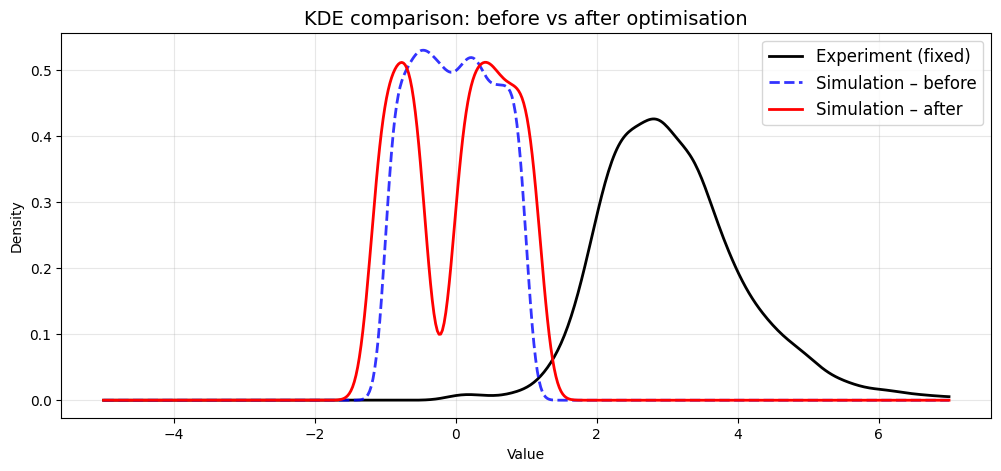

 18%|█▊        | 9/50 [00:05<00:25,  1.63it/s]

Step  10 | Loss = 0.343488


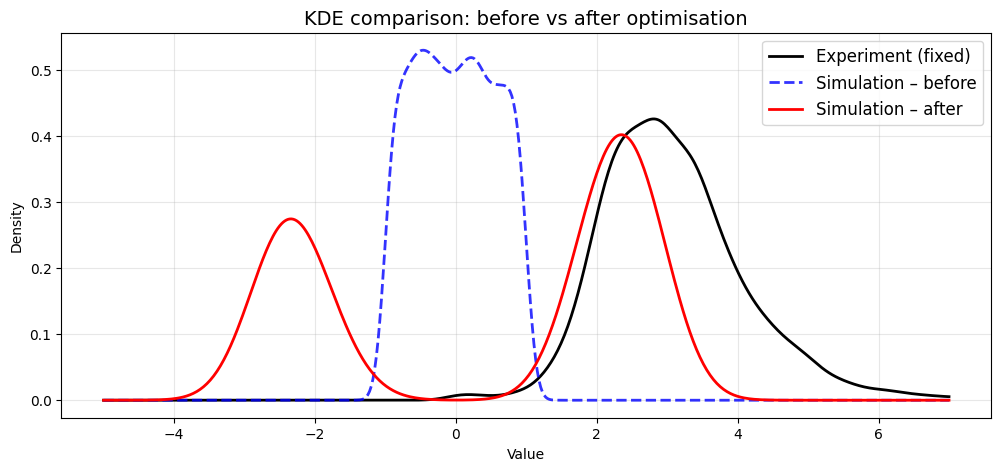

 38%|███▊      | 19/50 [00:11<00:16,  1.92it/s]

Step  20 | Loss = 0.201396


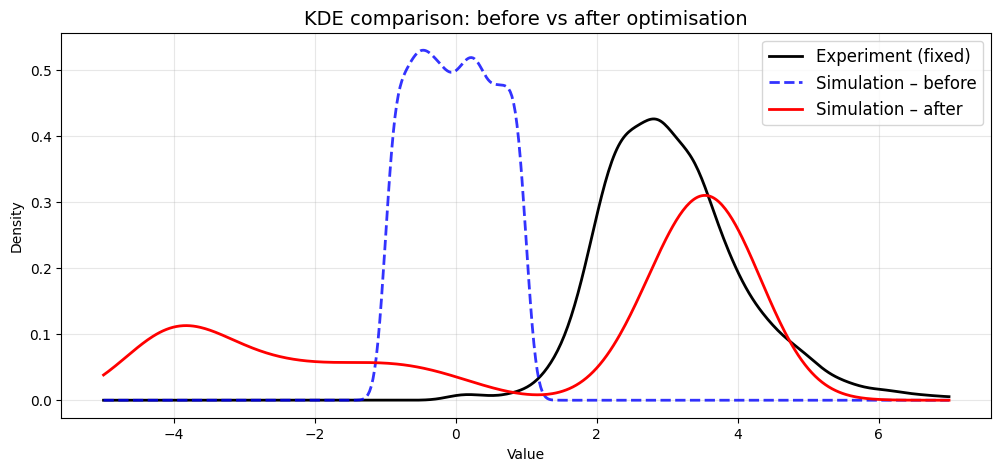

 58%|█████▊    | 29/50 [00:17<00:13,  1.57it/s]

Step  30 | Loss = 0.106629


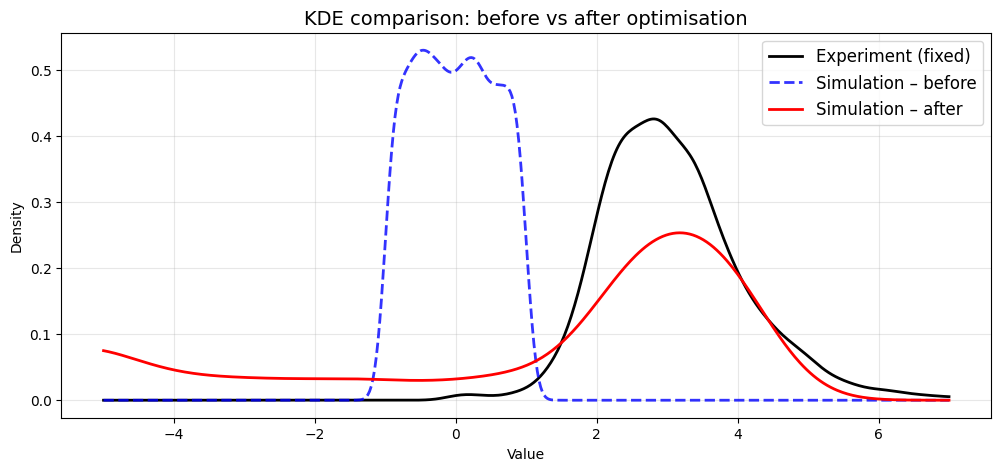

 78%|███████▊  | 39/50 [00:24<00:06,  1.60it/s]

Step  40 | Loss = 0.057690


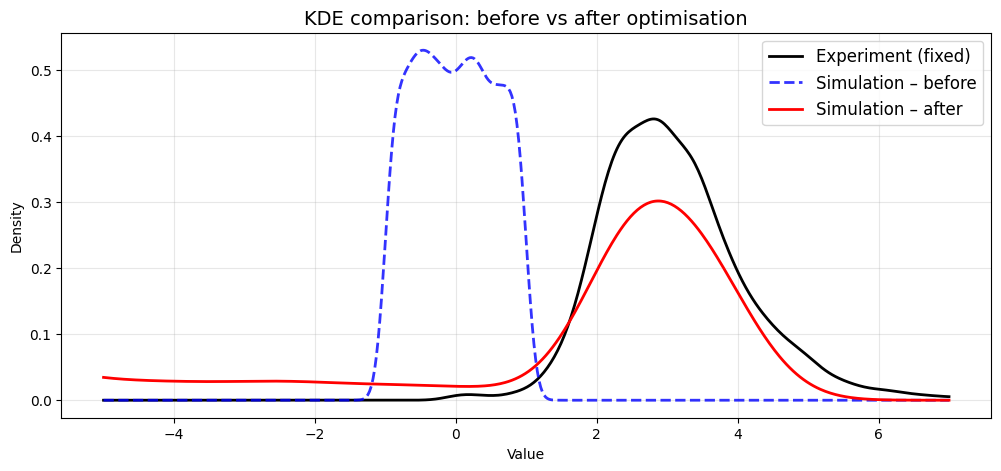

 98%|█████████▊| 49/50 [00:31<00:00,  1.54it/s]

Step  50 | Loss = 0.043237


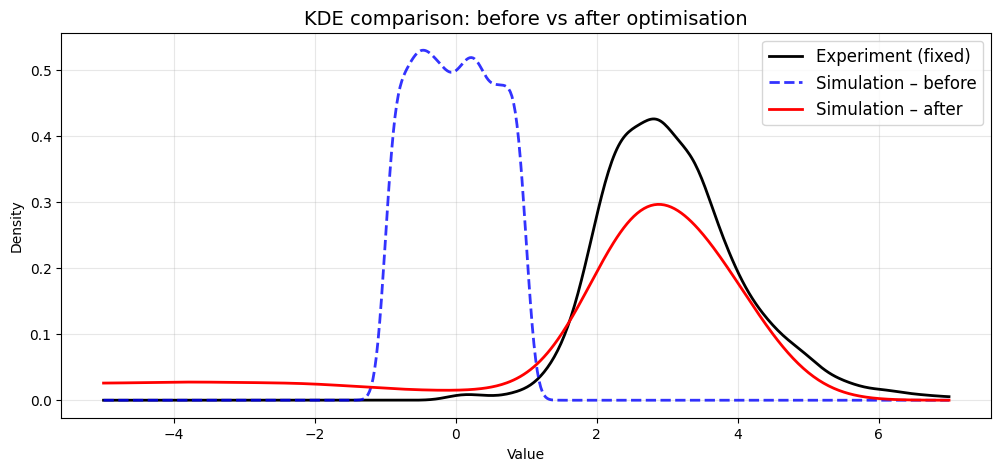

100%|██████████| 50/50 [00:32<00:00,  1.52it/s]


In [45]:

num_steps = 50
for step in tqdm(range(1, num_steps + 1)):
    optimizer.zero_grad()
    loss = mmd_loss(exp_data, sim_data)
    loss.backward()
    optimizer.step()

    if (step % 10 == 0) or (step == 1):
        print(f"Step {step:3d} | Loss = {loss.item():.6f}")
        sim_final_np = sim_data.detach().numpy()
        kde_sim_final = gaussian_kde(sim_final_np)

        # ------------------- Visualisation -------------------
        plt.figure(figsize=(12, 5))

        # Plot experiment KDE
        plt.plot(x_grid, kde_exp(x_grid), 'k-', linewidth=2, label='Experiment (fixed)')

        # Plot initial simulation KDE
        plt.plot(x_grid, kde_sim_init(x_grid), 'b--', linewidth=2, alpha=0.8, label='Simulation – before')

        # Plot final simulation KDE
        plt.plot(x_grid, kde_sim_final(x_grid), 'r-', linewidth=2, label='Simulation – after')

        plt.legend(fontsize=12)
        plt.title('KDE comparison: before vs after optimisation', fontsize=14)
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.grid(alpha=0.3)
        plt.show()


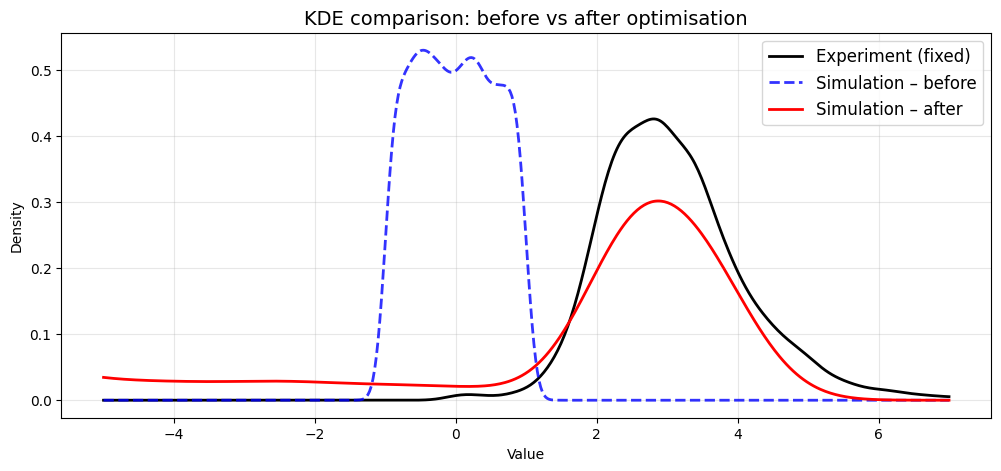

In [39]:

# ------------------- KDE after optimisation -------------------
sim_final_np = sim_data.detach().numpy()
kde_sim_final = gaussian_kde(sim_final_np)

# ------------------- Visualisation -------------------
plt.figure(figsize=(12, 5))

# Plot experiment KDE
plt.plot(x_grid, kde_exp(x_grid), 'k-', linewidth=2, label='Experiment (fixed)')

# Plot initial simulation KDE
plt.plot(x_grid, kde_sim_init(x_grid), 'b--', linewidth=2, alpha=0.8, label='Simulation – before')

# Plot final simulation KDE
plt.plot(x_grid, kde_sim_final(x_grid), 'r-', linewidth=2, label='Simulation – after')

plt.legend(fontsize=12)
plt.title('KDE comparison: before vs after optimisation', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.show()

## Sigma Tuning

The median-heuristic kernel bandwidth $\sigma$ optimises the **mean** but collapses the **spread**.
Here we sweep $\sigma$ from very small ($0.01 \times \sigma_{\text{median}}$) to large ($4 \times \sigma_{\text{median}}$)
to find which bandwidth lets MMD$^2$ capture both the mean **and** the variance of the experimental distribution.
All 10 optimisations start from the **same** uniform noise seed, so differences are purely due to $\sigma$.


Median-heuristic sigma = 0.8937


10it [04:18, 25.90s/it]


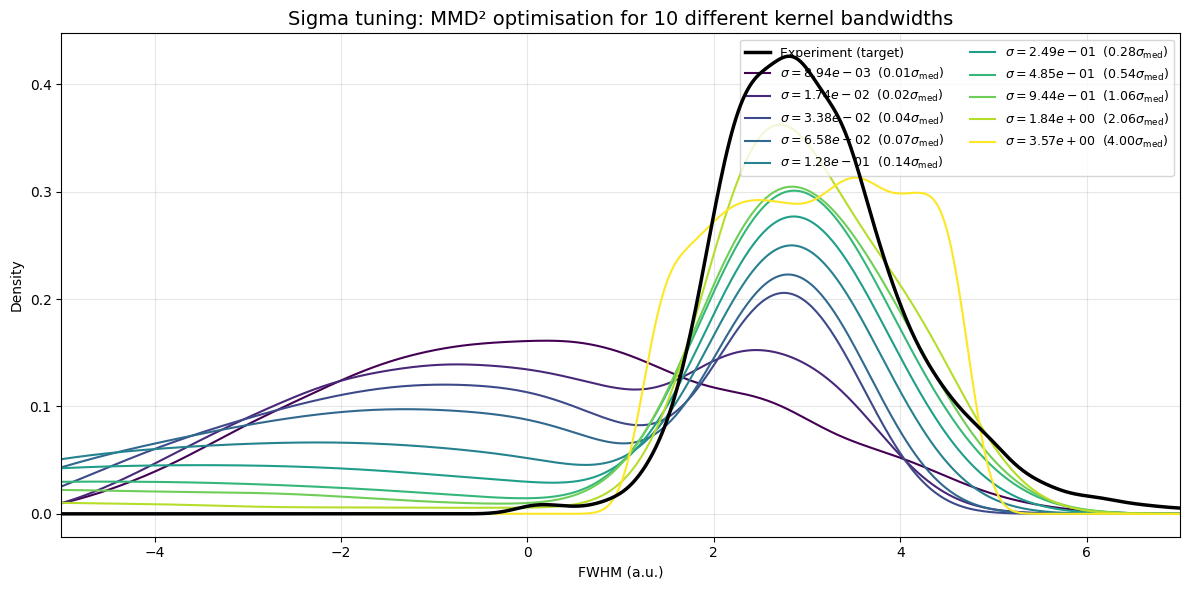

In [13]:
# ------------------- MMD with fixed sigma (no median heuristic) -------------------
def mmd_loss_fixed_sigma(x, y, sigma):
    """MMD² with a user-specified kernel bandwidth (no median heuristic)."""
    if x.dim() == 1:
        x = x.unsqueeze(1)
        y = y.unsqueeze(1)

    xx = torch.cdist(x, x, p=2).pow(2)
    yy = torch.cdist(y, y, p=2).pow(2)
    xy = torch.cdist(x, y, p=2).pow(2)

    K_xx = torch.exp(-xx / (2 * sigma**2))
    K_yy = torch.exp(-yy / (2 * sigma**2))
    K_xy = torch.exp(-xy / (2 * sigma**2))

    return K_xx.mean() + K_yy.mean() - 2 * K_xy.mean()


# ------------------- Compute median-heuristic sigma as reference -------------------
with torch.no_grad():
    xy_flat = torch.cdist(exp_data.unsqueeze(1), exp_data.unsqueeze(1), p=2).pow(2).flatten()
    sigma_median = torch.median(xy_flat).sqrt().item()
print(f"Median-heuristic sigma = {sigma_median:.4f}")


# ------------------- Sweep sigma -------------------
n_sigmas = 10
sigma_factors = np.geomspace(0.01, 4.0, n_sigmas)  # from 1% to 4x the median
sigma_values = sigma_median * sigma_factors
n_steps = 100
lr = 0.2
n_points = len(exp_data)

plt.figure(figsize=(12, 6))
cmap = plt.cm.viridis

# Plot target (experimental) distribution once
plt.plot(x_grid, kde_exp(x_grid), 'k-', linewidth=2.5, label='Experiment (target)', zorder=10)

for i, (factor, sigma_val) in tqdm(enumerate(zip(sigma_factors, sigma_values))):
    torch.manual_seed(42)  # same initial noise for every sigma
    sim = torch.rand(n_points) * 2 - 1
    sim.requires_grad = True

    optimizer = torch.optim.Adam([sim], lr=lr)

    for step in range(n_steps):
        optimizer.zero_grad()
        loss = mmd_loss_fixed_sigma(exp_data, sim, sigma_val)
        loss.backward()
        optimizer.step()

    # KDE of the optimised result
    sim_final = sim.detach().numpy()
    kde_final = gaussian_kde(sim_final)
    color = cmap(i / (n_sigmas - 1))
    plt.plot(x_grid, kde_final(x_grid), color=color, lw=1.5,
             label=f'$\\sigma = {sigma_val:.2e}$  ({factor:.2f}$\\sigma_{{\\mathrm{{med}}}}$)')

plt.legend(fontsize=9, loc='upper right', ncol=2)
plt.title(f'Sigma tuning: MMD² optimisation for {n_sigmas} different kernel bandwidths', fontsize=14)
plt.xlabel('FWHM (a.u.)')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.xlim(-5, 7)
plt.tight_layout()
plt.show()